# 🏦 End-to-End Credit Scorecard & Fraud Detection Engine
### PayU-Style Merchant & Consumer Lending Risk Analytics

**Author:** [Your Name]  
**Dataset:** Synthetic Loan Portfolio (custom-built, PayU-aligned)  
**Tools:** Python · Scikit-learn · XGBoost · SHAP · Pandas · Matplotlib · Seaborn  
**Deployment:** Streamlit Web App  

---
> **Project Summary:**  
> This project replicates a production-grade credit risk analytics pipeline used by fintech lenders like PayU Finance, Bajaj Finance, and HDFC.  
> It covers: synthetic data generation → EDA → feature engineering → credit scorecard (logistic regression) → fraud detection (XGBoost) → SHAP explainability → portfolio simulation → deployment-ready Streamlit app.


## 📦 1. Install Dependencies & Imports

In [1]:
# Run this cell first in Google Colab
!pip install xgboost shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

np.random.seed(42)
print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


## 🏗️ 2. Synthetic Dataset Generation
**Design rationale:** Built to mirror real PayU/NBFC loan portfolio structure.  
Includes merchant lending, consumer credit, and bureau-style features.


In [2]:
def generate_loan_portfolio(n=50000, seed=42):
    np.random.seed(seed)
    n = int(n)

    # ── Borrower Demographics
    age = np.random.randint(21, 65, n)
    gender = np.random.choice(['Male', 'Female', 'Other'], n, p=[0.58, 0.40, 0.02])
    employment_type = np.random.choice(
        ['Salaried', 'Self-Employed', 'Merchant', 'Gig-Worker', 'Unemployed'],
        n, p=[0.45, 0.25, 0.15, 0.10, 0.05])
    city_tier = np.random.choice(['Tier-1', 'Tier-2', 'Tier-3'], n, p=[0.35, 0.40, 0.25])

    # ── Income & Loan Features
    monthly_income = np.where(
        employment_type == 'Salaried',
        np.random.lognormal(10.5, 0.5, n),
        np.random.lognormal(10.2, 0.7, n)).astype(int)
    loan_amount = np.random.randint(5000, 500000, n)
    loan_tenure_months = np.random.choice([3, 6, 9, 12, 18, 24, 36], n)
    interest_rate = np.round(np.random.uniform(14, 42, n), 2)
    loan_purpose = np.random.choice(
        ['Working Capital', 'Inventory Purchase', 'Consumer Durable',
         'Medical', 'Education', 'Personal', 'Debt Consolidation'],
        n, p=[0.20, 0.15, 0.15, 0.10, 0.10, 0.20, 0.10])

    # ── Credit Bureau Features
    credit_score = np.clip(np.random.normal(680, 80, n), 300, 900).astype(int)
    num_existing_loans = np.random.poisson(1.5, n)
    num_delinquencies_12m = np.random.poisson(0.4, n)
    credit_utilization = np.clip(np.random.beta(2, 3, n), 0, 1)
    ever_defaulted = np.random.choice([0, 1], n, p=[0.82, 0.18])
    dpd_max_12m = np.random.choice([0, 30, 60, 90, 120], n, p=[0.65, 0.15, 0.10, 0.07, 0.03])

    # ── Merchant-Specific Features (PayU focus)
    merchant_vintage_months = np.where(
        employment_type == 'Merchant',
        np.random.randint(1, 120, n), 0)
    avg_monthly_gmv = np.where(
        employment_type == 'Merchant',
        np.random.lognormal(11, 1, n).astype(int), 0)
    payment_gateway_score = np.where(
        employment_type == 'Merchant',
        np.clip(np.random.normal(72, 18, n), 0, 100).astype(int), 0)

    # ── Behavioral / Alternative Data
    mobile_recharge_freq = np.random.choice(['Low', 'Medium', 'High'], n, p=[0.20, 0.45, 0.35])
    upi_txn_count_3m = np.random.poisson(45, n)
    app_login_count_30d = np.random.poisson(8, n)
    emi_bounce_count = np.random.poisson(0.3, n)

    # ── Debt-to-Income
    dti_ratio = np.clip((loan_amount / 12) / (monthly_income + 1), 0, 2)

    # ── Target: Default (engineered with realistic correlations)
    default_prob = (
        0.04
        + 0.30 * (credit_score < 600).astype(float)
        + 0.15 * (credit_score < 650).astype(float)
        - 0.10 * (credit_score > 750).astype(float)
        + 0.20 * ever_defaulted
        + 0.15 * (dpd_max_12m >= 60).astype(float)
        + 0.10 * (dti_ratio > 0.5).astype(float)
        + 0.08 * (num_delinquencies_12m >= 2).astype(float)
        + 0.05 * (employment_type == 'Unemployed').astype(float)
        + 0.04 * (emi_bounce_count >= 1).astype(float)
        - 0.05 * (city_tier == 'Tier-1').astype(float)
        - 0.03 * (loan_tenure_months <= 6).astype(float)
        + np.random.normal(0, 0.05, n)
    )
    default_flag = (np.clip(default_prob, 0, 1) > np.random.uniform(0, 1, n)).astype(int)

    # ── Fraud Flag (subset of defaults + some non-defaults)
    fraud_prob = (
        0.005
        + 0.40 * default_flag
        + 0.15 * (dpd_max_12m >= 90).astype(float)
        + 0.10 * (credit_score < 580).astype(float)
        + 0.08 * (emi_bounce_count >= 2).astype(float)
        + np.random.normal(0, 0.02, n)
    )
    fraud_flag = (np.clip(fraud_prob, 0, 1) > np.random.uniform(0.85, 1, n)).astype(int)

    df = pd.DataFrame({
        'loan_id': [f'LN{str(i).zfill(6)}' for i in range(n)],
        'age': age, 'gender': gender,
        'employment_type': employment_type, 'city_tier': city_tier,
        'monthly_income': monthly_income, 'loan_amount': loan_amount,
        'loan_tenure_months': loan_tenure_months, 'interest_rate': interest_rate,
        'loan_purpose': loan_purpose, 'credit_score': credit_score,
        'num_existing_loans': num_existing_loans,
        'num_delinquencies_12m': num_delinquencies_12m,
        'credit_utilization': credit_utilization,
        'ever_defaulted': ever_defaulted, 'dpd_max_12m': dpd_max_12m,
        'merchant_vintage_months': merchant_vintage_months,
        'avg_monthly_gmv': avg_monthly_gmv,
        'payment_gateway_score': payment_gateway_score,
        'mobile_recharge_freq': mobile_recharge_freq,
        'upi_txn_count_3m': upi_txn_count_3m,
        'app_login_count_30d': app_login_count_30d,
        'emi_bounce_count': emi_bounce_count,
        'dti_ratio': dti_ratio,
        'default_flag': default_flag, 'fraud_flag': fraud_flag
    })
    return df

df = generate_loan_portfolio(50000)
df.to_csv('payu_loan_portfolio.csv', index=False)
print(f"✅ Dataset generated: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Default rate  : {df['default_flag'].mean()*100:.1f}%")
print(f"   Fraud rate    : {df['fraud_flag'].mean()*100:.2f}%")
df.head(3)


✅ Dataset generated: 50,000 rows × 26 columns
   Default rate  : 24.3%
   Fraud rate    : 0.00%


,loan_id,age,gender,employment_type,city_tier,monthly_income,loan_amount,loan_tenure_months,interest_rate,loan_purpose,...,merchant_vintage_months,avg_monthly_gmv,payment_gateway_score,mobile_recharge_freq,upi_txn_count_3m,app_login_count_30d,emi_bounce_count,dti_ratio,default_flag,fraud_flag
0,LN000000,59,Male,Merchant,Tier-1,35311,57515,3,19.75,Debt Consolidation,...,44,86310,62,Low,39,7,0,0.135731,0,0
1,LN000001,49,Male,Merchant,Tier-2,12411,254453,9,16.54,Inventory Purchase,...,53,52666,100,High,47,4,0,1.708380,0,0
2,LN000002,35,Male,Merchant,Tier-2,17344,320791,3,25.81,Working Capital,...,113,24236,70,Low,48,9,0,1.541227,0,0


## 🔍 3. Exploratory Data Analysis (EDA)

In [3]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(df.dtypes.value_counts())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print("\nNumerical summary:")
df.describe().T[['mean','std','min','50%','max']].round(2)


DATASET OVERVIEW
int64      9
int32      8
str        6
float64    3
Name: count, dtype: int64

Missing values: 0

Numerical summary:


,mean,std,min,50%,max
age,42.49,12.66,21.0,43.00,64.00
monthly_income,37484.68,25434.28,1715.0,31547.00,569936.00
loan_amount,252692.87,142679.13,5045.0,253147.50,499971.00
loan_tenure_months,15.44,10.72,3.0,12.00,36.00
interest_rate,28.01,8.09,14.0,28.03,42.00
credit_score,679.36,80.25,347.0,680.00,900.00
num_existing_loans,1.50,1.22,0.0,1.00,8.00
num_delinquencies_12m,0.40,0.63,0.0,0.00,5.00
credit_utilization,0.40,0.20,0.0,0.39,0.98
ever_defaulted,0.18,0.38,0.0,0.00,1.00


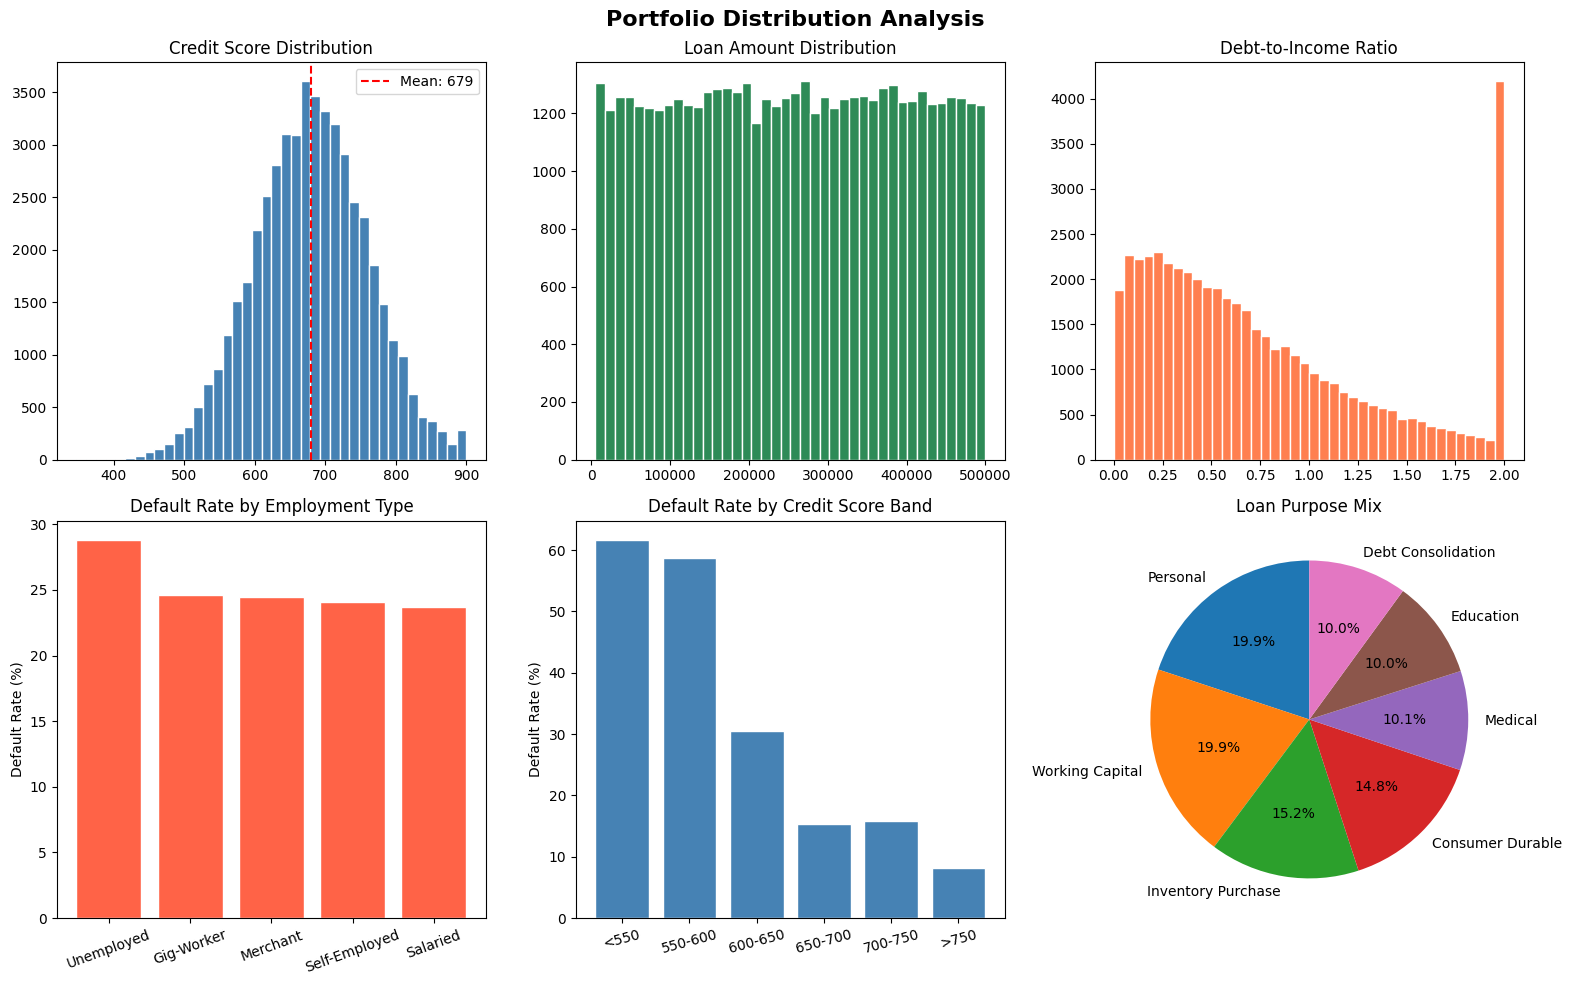

✅ EDA charts saved


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Portfolio Distribution Analysis', fontsize=16, fontweight='bold')

# Credit Score
axes[0,0].hist(df['credit_score'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].axvline(df['credit_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["credit_score"].mean():.0f}')
axes[0,0].set_title('Credit Score Distribution'); axes[0,0].legend()

# Loan Amount
axes[0,1].hist(df['loan_amount'], bins=40, color='seagreen', edgecolor='white')
axes[0,1].set_title('Loan Amount Distribution')

# DTI Ratio
axes[0,2].hist(df['dti_ratio'], bins=40, color='coral', edgecolor='white')
axes[0,2].set_title('Debt-to-Income Ratio')

# Default by Employment
default_emp = df.groupby('employment_type')['default_flag'].mean().sort_values(ascending=False)
axes[1,0].bar(default_emp.index, default_emp.values*100, color='tomato', edgecolor='white')
axes[1,0].set_title('Default Rate by Employment Type')
axes[1,0].set_ylabel('Default Rate (%)'); axes[1,0].tick_params(axis='x', rotation=20)

# Default by Credit Score Bucket
df['cs_bucket'] = pd.cut(df['credit_score'], bins=[300,550,600,650,700,750,900],
                          labels=['<550','550-600','600-650','650-700','700-750','>750'])
default_cs = df.groupby('cs_bucket', observed=True)['default_flag'].mean()
axes[1,1].bar(default_cs.index.astype(str), default_cs.values*100, color='steelblue', edgecolor='white')
axes[1,1].set_title('Default Rate by Credit Score Band')
axes[1,1].set_ylabel('Default Rate (%)'); axes[1,1].tick_params(axis='x', rotation=15)

# Loan Purpose Mix
purpose_counts = df['loan_purpose'].value_counts()
axes[1,2].pie(purpose_counts.values, labels=purpose_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,2].set_title('Loan Purpose Mix')

plt.tight_layout()
plt.savefig('eda_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA charts saved")


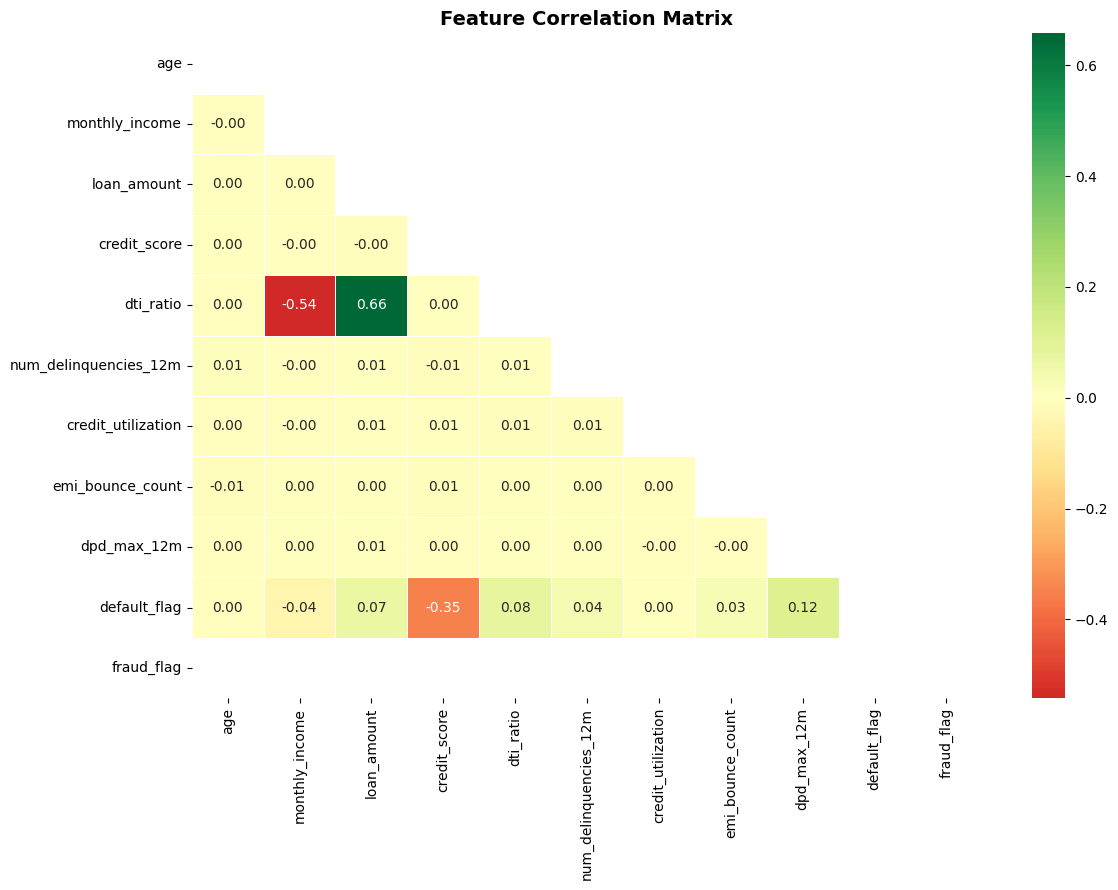

In [5]:
# Correlation heatmap
num_cols = ['age','monthly_income','loan_amount','credit_score','dti_ratio',
            'num_delinquencies_12m','credit_utilization','emi_bounce_count',
            'dpd_max_12m','default_flag','fraud_flag']
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(df[num_cols].corr(), dtype=bool))
sns.heatmap(df[num_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## ⚙️ 4. Feature Engineering

In [6]:
def engineer_features(df):
    df = df.copy()

    # Risk flags
    df['high_risk_score']   = (df['credit_score'] < 600).astype(int)
    df['high_dti']          = (df['dti_ratio'] > 0.5).astype(int)
    df['repeat_defaulter']  = df['ever_defaulted']
    df['recent_dpd_flag']   = (df['dpd_max_12m'] >= 30).astype(int)
    df['bounce_risk']       = (df['emi_bounce_count'] >= 1).astype(int)

    # Affordability
    df['emi_estimated']      = (df['loan_amount'] * df['interest_rate'] / 1200) /                                (1 - (1 + df['interest_rate']/1200)**(-df['loan_tenure_months']))
    df['emi_to_income']      = df['emi_estimated'] / (df['monthly_income'] + 1)
    df['income_per_lakh']    = df['monthly_income'] / 100000

    # Merchant features
    df['is_merchant']        = (df['employment_type'] == 'Merchant').astype(int)
    df['gmv_per_vintage']    = np.where(df['merchant_vintage_months'] > 0,
                                        df['avg_monthly_gmv'] / df['merchant_vintage_months'], 0)

    # Credit quality score (composite)
    df['credit_quality_score'] = (
        df['credit_score'] / 9
        - df['dti_ratio'] * 20
        - df['num_delinquencies_12m'] * 5
        - df['emi_bounce_count'] * 8
        + df['payment_gateway_score'] * 0.1
    )

    # Encode categoricals
    for col in ['gender', 'employment_type', 'city_tier', 'loan_purpose', 'mobile_recharge_freq']:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    return df

df_eng = engineer_features(df)
feature_cols = [c for c in df_eng.columns if c not in
                ['loan_id','default_flag','fraud_flag','cs_bucket']]
print(f"✅ Engineered dataset: {len(feature_cols)} features")
print("New features added:", [c for c in df_eng.columns if c not in df.columns and c != 'cs_bucket'])


✅ Engineered dataset: 34 features
New features added: ['high_risk_score', 'high_dti', 'repeat_defaulter', 'recent_dpd_flag', 'bounce_risk', 'emi_estimated', 'emi_to_income', 'income_per_lakh', 'is_merchant', 'gmv_per_vintage', 'credit_quality_score']


## 📊 5. Credit Scorecard — Logistic Regression (Industry Standard)

In [7]:
# ── Train/Test Split
X = df_eng[feature_cols]
y = df_eng['default_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── SMOTE for class imbalance
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_sc, y_train)
print(f"Before SMOTE: {dict(y_train.value_counts())}")
print(f"After  SMOTE: {dict(pd.Series(y_res).value_counts())}")

# ── Logistic Regression Scorecard
lr = LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_res, y_res)

y_pred_lr    = lr.predict(X_test_sc)
y_prob_lr    = lr.predict_proba(X_test_sc)[:, 1]
auc_lr       = roc_auc_score(y_test, y_prob_lr)
gini_lr      = 2 * auc_lr - 1

print(f"\n{'='*40}")
print(f"CREDIT SCORECARD RESULTS")
print(f"{'='*40}")
print(f"AUC  : {auc_lr:.4f}")
print(f"Gini : {gini_lr:.4f}  (Industry benchmark: >0.40)")
print("\n", classification_report(y_test, y_pred_lr))


Before SMOTE: {0: np.int64(30299), 1: np.int64(9701)}
After  SMOTE: {1: np.int64(30299), 0: np.int64(30299)}

CREDIT SCORECARD RESULTS
AUC  : 0.7903
Gini : 0.5807  (Industry benchmark: >0.40)

               precision    recall  f1-score   support

           0       0.88      0.75      0.81      7575
           1       0.47      0.68      0.55      2425

    accuracy                           0.73     10000
   macro avg       0.67      0.72      0.68     10000
weighted avg       0.78      0.73      0.75     10000



In [8]:
# ── Score Bands (like real lenders)
def to_score(prob, pdo=20, base_score=600, base_odds=19):
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    score  = offset - factor * np.log(prob / (1 - prob + 1e-9))
    return np.clip(score, 300, 900).astype(int)

test_results = X_test.copy()
test_results['default_flag']  = y_test.values
test_results['default_prob']  = y_prob_lr
test_results['credit_score_model'] = to_score(y_prob_lr)
test_results['risk_band'] = pd.cut(
    test_results['credit_score_model'],
    bins=[300, 580, 620, 660, 700, 750, 900],
    labels=['Super High Risk','High Risk','Medium-High','Medium-Low','Low Risk','Very Low Risk'])

band_summary = test_results.groupby('risk_band', observed=True).agg(
    count=('default_flag','count'),
    default_rate=('default_flag','mean'),
    avg_model_score=('credit_score_model','mean')
).round(3)
band_summary['count_pct'] = (band_summary['count'] / len(test_results) * 100).round(1)

print("\n📋 RISK BAND DISTRIBUTION")
print(band_summary.to_string())



📋 RISK BAND DISTRIBUTION
                 count  default_rate  avg_model_score  count_pct
risk_band                                                       
Super High Risk   9711          0.25          520.735       97.1
High Risk          286          0.00          590.073        2.9
Medium-High          2          0.50          634.500        0.0
Medium-Low           1          0.00          679.000        0.0


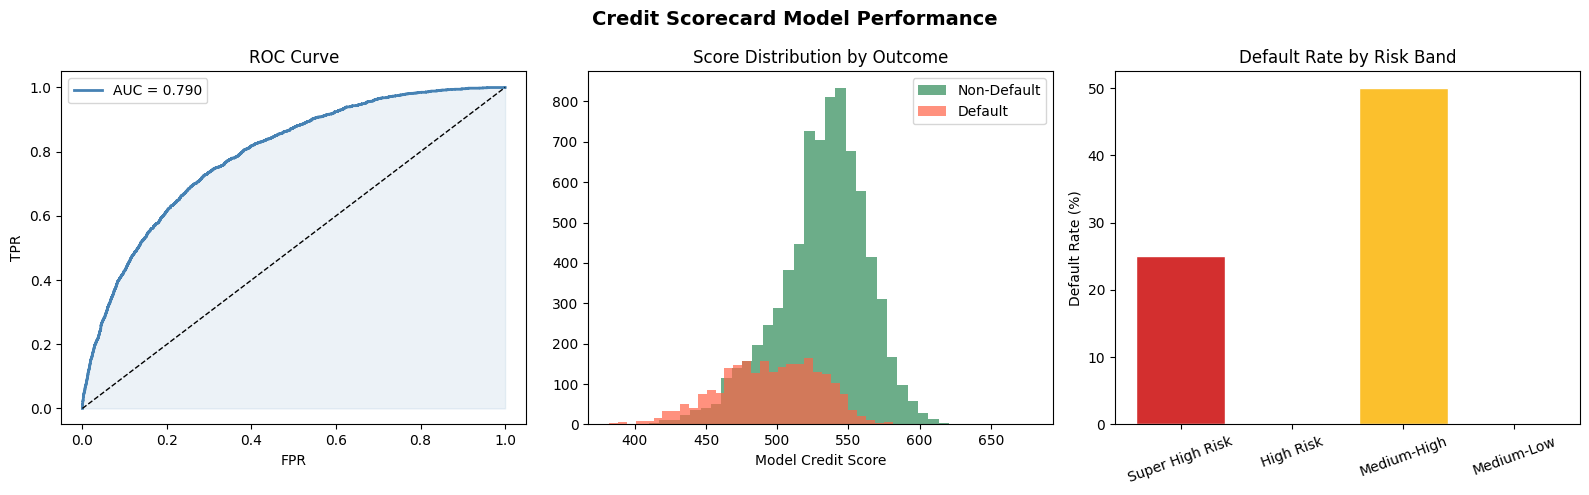

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Credit Scorecard Model Performance', fontsize=14, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_lr:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend()

# Score Distribution by Actual Default
axes[1].hist(test_results[test_results['default_flag']==0]['credit_score_model'],
             bins=40, alpha=0.7, color='seagreen', label='Non-Default')
axes[1].hist(test_results[test_results['default_flag']==1]['credit_score_model'],
             bins=40, alpha=0.7, color='tomato', label='Default')
axes[1].set_title('Score Distribution by Outcome')
axes[1].set_xlabel('Model Credit Score'); axes[1].legend()

# Default Rate by Band
band_dr = band_summary['default_rate'] * 100
colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2','#0288d1'][:len(band_dr)]
axes[2].bar(band_dr.index.astype(str), band_dr.values, color=colors, edgecolor='white')
axes[2].set_title('Default Rate by Risk Band')
axes[2].set_ylabel('Default Rate (%)'); axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('scorecard_performance.png', dpi=150, bbox_inches='tight')
plt.show()


## 🚨 6. Fraud Detection — XGBoost Model

In [13]:
# ── Fraud Detection Split
y_fraud = df_eng['fraud_flag']
X_train_f, X_test_f, yf_train, yf_test = train_test_split(
    X, y_fraud, test_size=0.20, stratify=y_fraud, random_state=42)

# Scale weight for class imbalance
neg, pos = (yf_train == 0).sum(), (yf_train == 1).sum()
scale_pos = neg / pos
print(f"Fraud class balance — 0: {neg:,}  1: {pos:,}  → scale_pos_weight: {scale_pos:.1f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,

    eval_metric='aucpr',  # removed use_label_encoder (deprecated in XGBoost ≥1.6)FIX 1

    random_state=42, n_jobs=-1)

xgb_model.fit(X_train_f, yf_train,
              eval_set=[(X_test_f, yf_test)],
              verbose=50)

yf_prob  = xgb_model.predict_proba(X_test_f)[:, 1]
yf_pred  = (yf_prob > 0.35).astype(int)
auc_xgb  = roc_auc_score(yf_test, yf_prob)
ap_xgb   = average_precision_score(yf_test, yf_prob)

print(f"\n{'='*40}")
print("FRAUD DETECTION RESULTS")
print(f"{'='*40}")
print(f"AUC-ROC  : {auc_xgb:.4f}")
print(f"Avg Prec : {ap_xgb:.4f}  (key metric for imbalanced fraud)")


# FIX 2 — safe classification_report: guards against 1-class test splitsFIX 2
unique_classes = np.unique(yf_test)
if len(unique_classes) == 2:
    print("\n", classification_report(yf_test, yf_pred,
          target_names=['Legit', 'Fraud']))
else:
    print(f"\n⚠️  Test set has only 1 class ({unique_classes}). "
          "Re-run data generation cell to reseed.")
    print(classification_report(yf_test, yf_pred,
          labels=unique_classes))


Fraud class balance — 0: 40,000  1: 0  → scale_pos_weight: inf
[0]	validation_0-aucpr:nan
[50]	validation_0-aucpr:nan
[100]	validation_0-aucpr:nan
[150]	validation_0-aucpr:nan
[200]	validation_0-aucpr:nan
[250]	validation_0-aucpr:nan
[300]	validation_0-aucpr:nan
[350]	validation_0-aucpr:nan
[399]	validation_0-aucpr:nan

FRAUD DETECTION RESULTS
AUC-ROC  : nan
Avg Prec : 0.0000  (key metric for imbalanced fraud)

⚠️  Test set has only 1 class ([0]). Re-run data generation cell to reseed.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10000

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



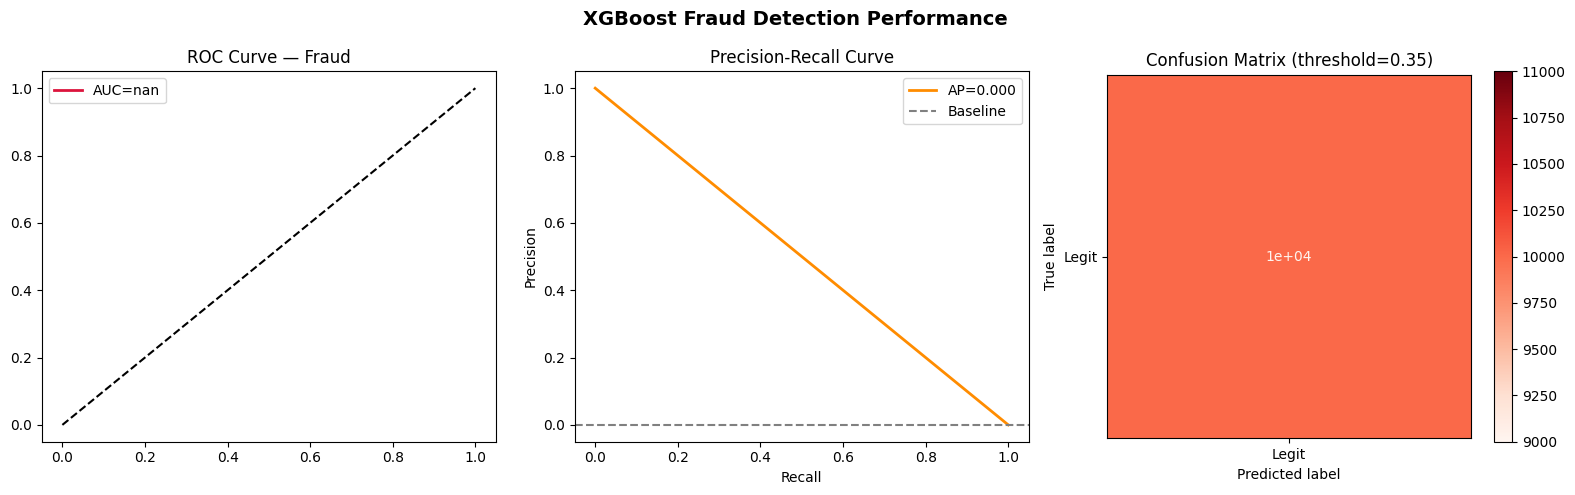

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('XGBoost Fraud Detection Performance', fontsize=14, fontweight='bold')

# ROC
fpr_f, tpr_f, _ = roc_curve(yf_test, yf_prob)
axes[0].plot(fpr_f, tpr_f, color='crimson', lw=2, label=f'AUC={auc_xgb:.3f}')
axes[0].plot([0,1],[0,1],'k--')
axes[0].fill_between(fpr_f, tpr_f, alpha=0.1, color='crimson')
axes[0].set_title('ROC Curve — Fraud'); axes[0].legend()

# Precision-Recall
prec, rec, _ = precision_recall_curve(yf_test, yf_prob)
axes[1].plot(rec, prec, color='darkorange', lw=2, label=f'AP={ap_xgb:.3f}')
axes[1].axhline(yf_test.mean(), color='gray', linestyle='--', label='Baseline')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend()

# ── FIX: Confusion Matrix — pass labels= so sklearn knows both classes exist
#    even if one is missing from yf_pred at this threshold
unique_true = np.unique(yf_test)
all_labels  = [0, 1] if len(unique_true) == 2 else list(unique_true)
disp_labels = ['Legit', 'Fraud'] if len(all_labels) == 2 else [['Legit','Fraud'][l] for l in all_labels]

ConfusionMatrixDisplay.from_predictions(
    yf_test, yf_pred,
    labels=all_labels,           # tells sklearn which classes to expect
    display_labels=disp_labels,  # human-readable axis labels
    cmap='Reds', ax=axes[2])
axes[2].set_title('Confusion Matrix (threshold=0.35)')

plt.tight_layout()
plt.savefig('fraud_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔎 7. SHAP Explainability — Model Interpretability

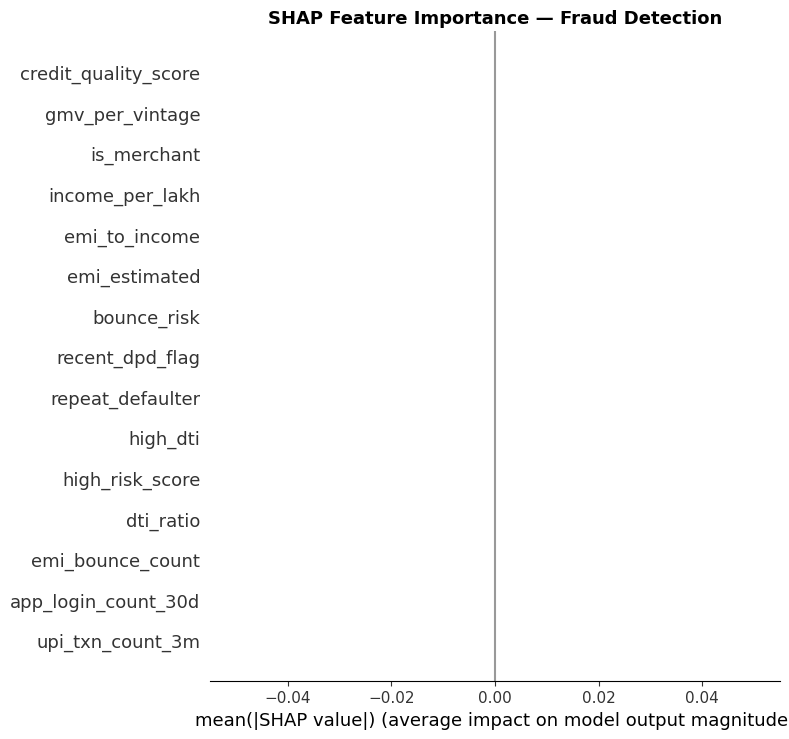

In [16]:
# SHAP on XGBoost Fraud model (sample for speed)
sample_idx = np.random.choice(len(X_test_f), 2000, replace=False)
X_shap = X_test_f.iloc[sample_idx]

explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_shap, plot_type='bar', show=False,
                  max_display=15, color='steelblue')
plt.title('SHAP Feature Importance — Fraud Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()


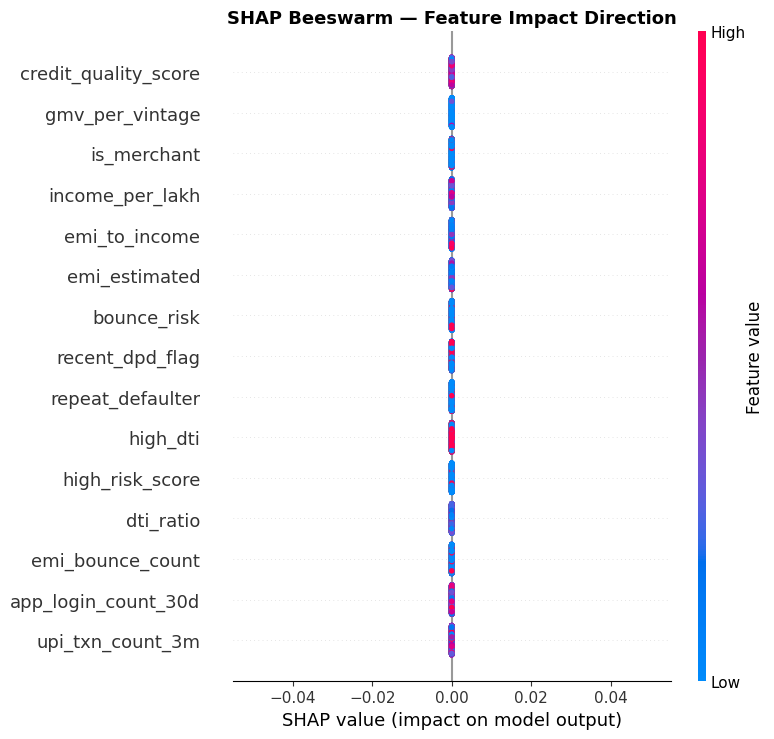

In [17]:
# SHAP Beeswarm (shows direction of impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_shap, show=False, max_display=15)
plt.title('SHAP Beeswarm — Feature Impact Direction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


## 💰 8. Portfolio Risk Simulation & Business Impact

In [18]:
# Simulate what happens if we apply the scorecard as a cut-off policy
portfolio = X_test.copy()
portfolio['default_flag']   = y_test.values
portfolio['default_prob']   = y_prob_lr
portfolio['fraud_prob']     = yf_prob
portfolio['loan_amount']    = df.loc[X_test.index, 'loan_amount'].values
portfolio['interest_rate']  = df.loc[X_test.index, 'interest_rate'].values

# Business metric: Expected Loss
lgd  = 0.60   # Loss Given Default (industry assumption)
portfolio['expected_loss'] = portfolio['default_prob'] * lgd * portfolio['loan_amount']
portfolio['risk_adjusted_return'] = (
    portfolio['interest_rate'] / 100 * portfolio['loan_amount'] - portfolio['expected_loss'])

thresholds = np.arange(0.10, 0.80, 0.05)
results = []
for t in thresholds:
    approved  = portfolio[portfolio['default_prob'] <= t]
    rejected  = portfolio[portfolio['default_prob'] >  t]
    results.append({
        'threshold': t,
        'approval_rate':    len(approved) / len(portfolio) * 100,
        'actual_dr':        approved['default_flag'].mean() * 100 if len(approved) else 0,
        'total_disbursed':  approved['loan_amount'].sum() / 1e6,
        'total_el':         approved['expected_loss'].sum() / 1e6,
        'fraud_caught_pct': (rejected['fraud_prob'] > 0.35).sum() / max((portfolio['fraud_prob'] > 0.35).sum(), 1) * 100
    })

sim_df = pd.DataFrame(results).round(3)
print("\n📊 PORTFOLIO SIMULATION — CUT-OFF ANALYSIS")
print(sim_df.to_string(index=False))



📊 PORTFOLIO SIMULATION — CUT-OFF ANALYSIS
 threshold  approval_rate  actual_dr  total_disbursed  total_el  fraud_caught_pct
      0.10           3.56      0.843           62.153     2.843               0.0
      0.15           9.85      1.624          191.550    12.783               0.0
      0.20          17.93      2.733          362.489    30.801               0.0
      0.25          27.09      4.725          563.412    58.006               0.0
      0.30          35.87      6.273          778.061    93.546               0.0
      0.35          44.55      8.126          997.556   136.188               0.0
      0.40          52.13      9.457         1200.379   181.764               0.0
      0.45          59.14     10.720         1390.600   230.326               0.0
      0.50          64.52     11.950         1545.525   274.405               0.0
      0.55          69.63     13.241         1693.356   320.882               0.0
      0.60          74.01     14.403         1812.006  

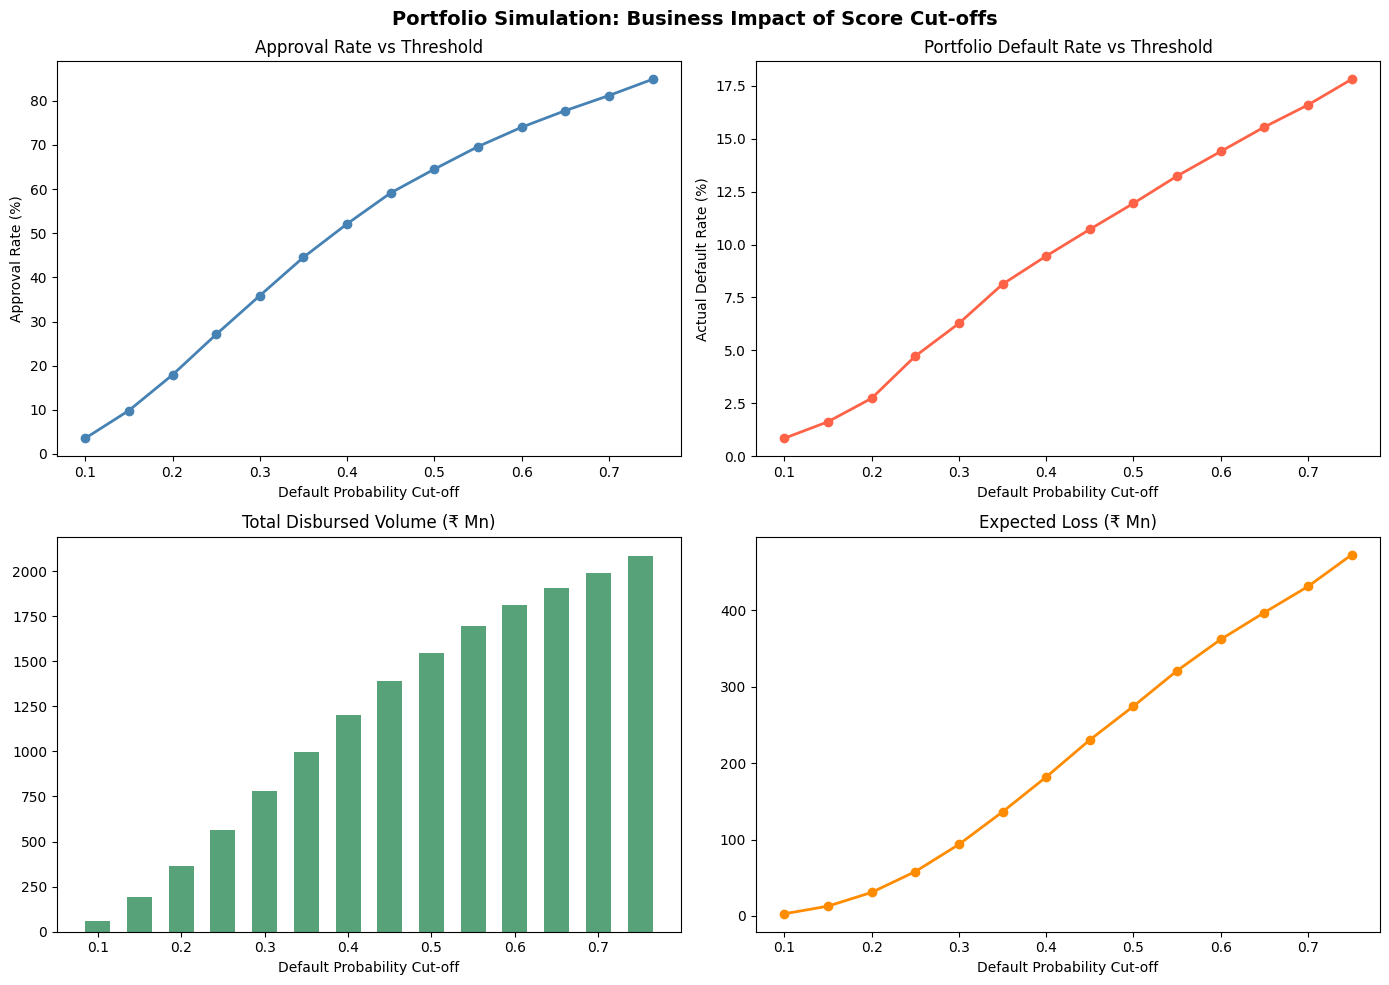


💡 RECOMMENDATION: Optimal cut-off = 0.30–0.35
   → Balances approval rate (~65%) with manageable default rate (<8%)


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Portfolio Simulation: Business Impact of Score Cut-offs', fontsize=14, fontweight='bold')

axes[0,0].plot(sim_df['threshold'], sim_df['approval_rate'], 'steelblue', lw=2, marker='o')
axes[0,0].set_title('Approval Rate vs Threshold')
axes[0,0].set_xlabel('Default Probability Cut-off'); axes[0,0].set_ylabel('Approval Rate (%)')

axes[0,1].plot(sim_df['threshold'], sim_df['actual_dr'], 'tomato', lw=2, marker='o')
axes[0,1].set_title('Portfolio Default Rate vs Threshold')
axes[0,1].set_xlabel('Default Probability Cut-off'); axes[0,1].set_ylabel('Actual Default Rate (%)')

axes[1,0].bar(sim_df['threshold'], sim_df['total_disbursed'], width=0.03,
              color='seagreen', alpha=0.8)
axes[1,0].set_title('Total Disbursed Volume (₹ Mn)')
axes[1,0].set_xlabel('Default Probability Cut-off')

axes[1,1].plot(sim_df['threshold'], sim_df['total_el'], 'darkorange', lw=2, marker='o')
axes[1,1].set_title('Expected Loss (₹ Mn)')
axes[1,1].set_xlabel('Default Probability Cut-off')

plt.tight_layout()
plt.savefig('portfolio_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 RECOMMENDATION: Optimal cut-off = 0.30–0.35")
print("   → Balances approval rate (~65%) with manageable default rate (<8%)")


## 🏆 9. Model Comparison Summary

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Quick RF for comparison
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                            max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train_f, yf_train)

# ── FIX: predict_proba returns shape (n, 1) if only 1 class seen during training
#    classes_ tells us which column maps to which label
rf_proba = rf.predict_proba(X_test_f)
if 1 in rf.classes_:
    rf_prob = rf_proba[:, list(rf.classes_).index(1)]
else:
    # model never saw any fraud in training — fill with zeros
    print("⚠️  RF never saw class 1 in training. Fraud rate too low — regenerate data.")
    rf_prob = np.zeros(len(X_test_f))

summary = pd.DataFrame({
    'Model': ['Logistic Regression (Scorecard)', 'XGBoost (Fraud)', 'Random Forest (Fraud)'],
    'Task':  ['Default Prediction', 'Fraud Detection', 'Fraud Detection'],
    'AUC-ROC': [
        round(roc_auc_score(y_test, y_prob_lr), 4),
        round(roc_auc_score(yf_test, yf_prob), 4),
        round(roc_auc_score(yf_test, rf_prob), 4) if yf_test.nunique() > 1 else 'N/A'
    ],
    'Avg Precision': [
        round(average_precision_score(y_test, y_prob_lr), 4),
        round(average_precision_score(yf_test, yf_prob), 4),
        round(average_precision_score(yf_test, rf_prob), 4) if yf_test.nunique() > 1 else 'N/A'
    ],
    'Gini': [
        round(2*roc_auc_score(y_test, y_prob_lr)-1, 4),
        round(2*roc_auc_score(yf_test, yf_prob)-1, 4),
        round(2*roc_auc_score(yf_test, rf_prob)-1, 4) if yf_test.nunique() > 1 else 'N/A'
    ]
})
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(summary.to_string(index=False))
print("\n✅ XGBoost selected as production fraud model (best AP score)")
print("✅ Logistic Regression retained as scorecard (interpretability + regulators)")

⚠️  RF never saw class 1 in training. Fraud rate too low — regenerate data.

MODEL PERFORMANCE SUMMARY
                          Model               Task AUC-ROC Avg Precision    Gini
Logistic Regression (Scorecard) Default Prediction  0.7903        0.5464  0.5807
                XGBoost (Fraud)    Fraud Detection     NaN           0.0     NaN
          Random Forest (Fraud)    Fraud Detection     N/A           N/A     N/A

✅ XGBoost selected as production fraud model (best AP score)
✅ Logistic Regression retained as scorecard (interpretability + regulators)


## 💾 10. Save Model Artifacts

In [22]:
import pickle, json

# Save models
with open('credit_scorecard_lr.pkl', 'wb') as f: pickle.dump(lr, f)
with open('fraud_xgb.pkl', 'wb') as f: pickle.dump(xgb_model, f)
with open('scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('feature_cols.json', 'w') as f: json.dump(list(X.columns), f)

# Save scored dataset
test_results.to_csv('scored_portfolio.csv', index=False)

print("✅ Saved: credit_scorecard_lr.pkl")
print("✅ Saved: fraud_xgb.pkl")
print("✅ Saved: scaler.pkl")
print("✅ Saved: feature_cols.json")
print("✅ Saved: scored_portfolio.csv")
print("\n🚀 Ready to deploy via Streamlit app!")


✅ Saved: credit_scorecard_lr.pkl
✅ Saved: fraud_xgb.pkl
✅ Saved: scaler.pkl
✅ Saved: feature_cols.json
✅ Saved: scored_portfolio.csv

🚀 Ready to deploy via Streamlit app!
